In [12]:
import pandas as pd 


In [ ]:
from src.data.main import data_preparation_pipeline

filepath = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/accepted_2007_to_2018Q4.csv"
want_sample = True 
features_to_keep = 13
X_train, X_val, X_test, y_train, y_val, y_test = data_preparation_pipeline(filepath=filepath, want_sample=want_sample, features_to_keep=features_to_keep)


Starting data preparation pipeline

    1. Loading Data 
    2. Cleaning (Removing Null Values and Irrelevant Columns)
    3. Splitting using Stratified Sampling
    3. Preprocessing + Feature Selection/Engineering
    
Reading and loading file ...


In [ ]:
data_splits = X_train, X_val, X_test, y_train, y_val, y_test

from src.utils import train_validation_metrics

In [ ]:
# things to compare: 
# 1. number of features 
# 2. presence of smote 
# 3. model type 
# 4. hyper parameters 

Training Metrics
F1 Score:0.7245709786598693
Recall score: 0.09676049760115485
Precision score: 0.5229463056447912
[[0.0967605  0.9032395 ]
 [0.02413513 0.97586487]]
ROC:0.7061579631928627
------------------------------------------------------------
Test Metrics
F1 Score:0.7271968066952034
Recall score: 0.1015625
Precision score: 0.5476190476190477
[[0.1015625  0.8984375 ]
 [0.02293834 0.97706166]]
ROC:0.7129242832527134


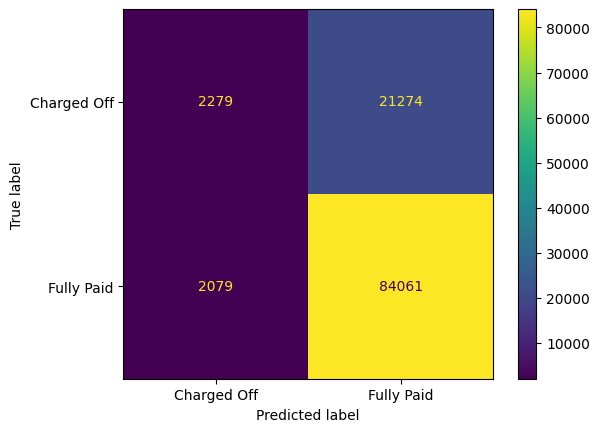

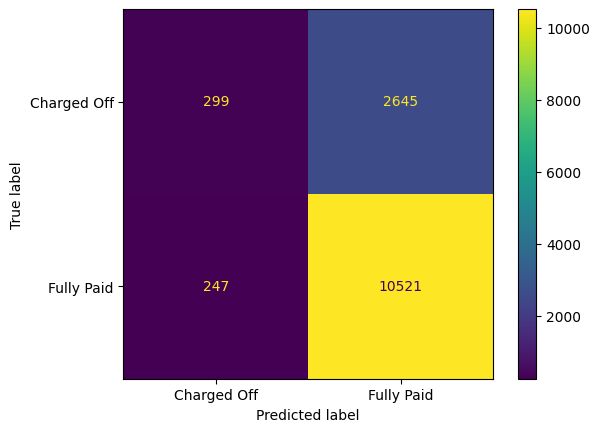

In [ ]:
## Model Baseline 

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

train_validation_metrics(data_splits=data_splits, model=lr, LGB=False)

Training Metrics
F1 Score:1.0
Recall score: 1.0
Precision score: 1.0
[[1. 0.]
 [0. 1.]]
ROC:1.0
------------------------------------------------------------
Test Metrics
F1 Score:0.6964287687028651
Recall score: 0.31589673913043476
Precision score: 0.297790585975024
[[0.31589674 0.68410326]
 [0.20365899 0.79634101]]
ROC:0.5561188747658117


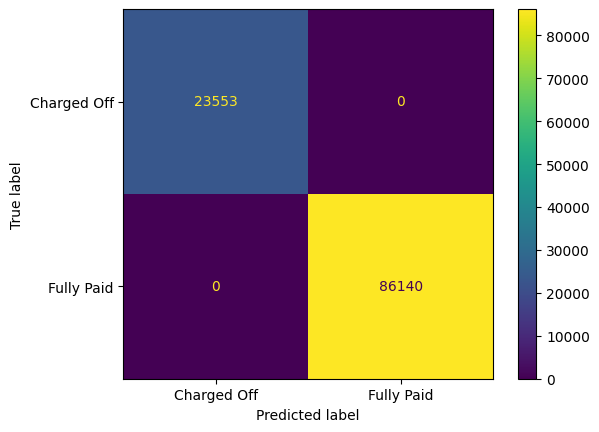

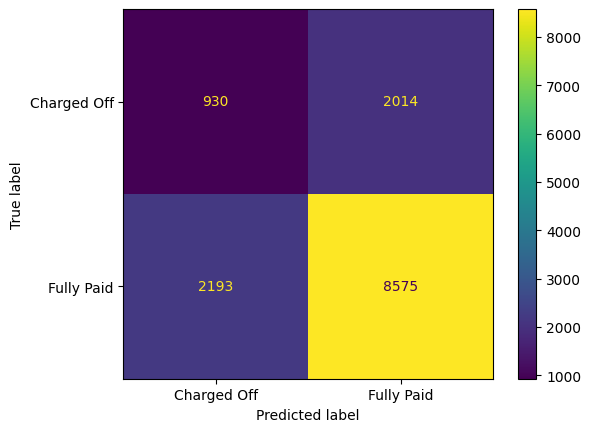

In [ ]:
from sklearn.tree import DecisionTreeClassifier

lr = DecisionTreeClassifier()

train_validation_metrics(data_splits=data_splits, model=lr, LGB=False)

Training Metrics
F1 Score:0.651324553685074
Recall score: 0.6736721436759648
Precision score: 0.3162520928007654
[[0.67367214 0.32632786]
 [0.39824704 0.60175296]]
ROC:0.6845360535843408
------------------------------------------------------------
Test Metrics
F1 Score:0.6581047319817678
Recall score: 0.6908967391304348
Precision score: 0.3243501833838303
[[0.69089674 0.30910326]
 [0.39348068 0.60651932]]
ROC:0.6965491174534855


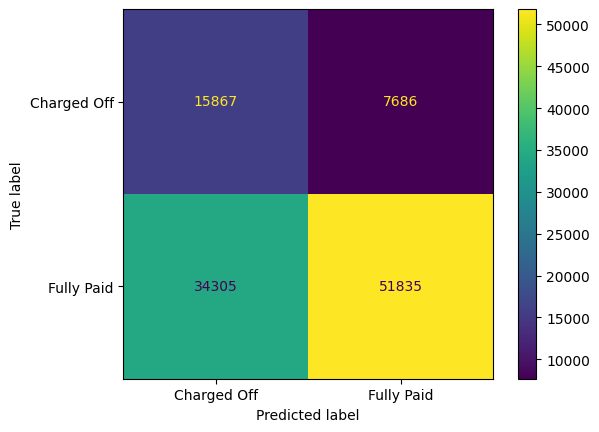

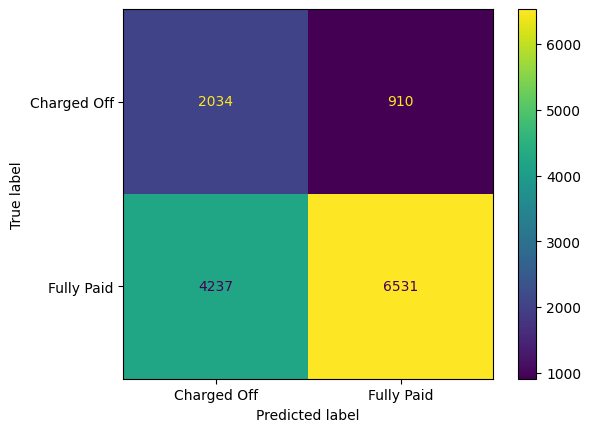

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth (start with 5-10)
    min_samples_split=100,    # Need at least 100 samples to split a node
    min_samples_leaf=50,      # Each leaf must have at least 50 samples
    max_features='sqrt',      # Only consider sqrt(n_features) at each split
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

train_validation_metrics(data_splits=data_splits, model=dt, LGB=False)

In [ ]:
len(y_val)

13712

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test 
for split in data_splits: 
    print(split.shape)

# something wrong with spltting 
# something wrong the dimensions dont add up the dimensions are not supposed to be the samee

(109693, 13)
(13712, 13)
(13712, 13)
(109693,)
(13712,)
(13712,)


In [1]:
import numpy as np

In [2]:
from src.data.feature_engineering import dropping_constant_features, correlation_analysis, mwu, test_of_independence, mutual_information
from src.data.preprocessing import initial_preprocessing, categorical_preprocessing

def processing_feature_selection_pipeline(X_train, X_val, X_test, y_train, features_to_keep):

    X_train = X_train.copy() 
    X_val = X_val.copy() 
    X_test = X_test.copy() 

    columns_to_drop = []

    X_train, X_val, X_test = initial_preprocessing(X_train=X_train, X_val=X_val, X_test=X_test)

    X_train, X_val, X_test = dropping_constant_features(X_train=X_train, X_val=X_val, X_test=X_test)

    grouped = X_train.merge(y_train, how='inner', left_index=True, right_index=True)

    charged_off = grouped.loc[grouped['loan_status'] == 'Charged Off']

    fully_paid = grouped.loc[grouped['loan_status'] == 'Fully Paid']

    columns_to_drop.extend(correlation_analysis(X_train=X_train, X_val=X_val, X_test=X_test))
    columns_to_drop.extend(mwu(charged_off=charged_off, fully_paid=fully_paid))
    columns_to_drop.extend(test_of_independence(X_train=X_train, whole_group=grouped))

    X_train.drop(columns_to_drop, axis=1, inplace=True) 
    X_val.drop(columns_to_drop, axis=1, inplace=True) 
    X_test.drop(columns_to_drop, axis=1, inplace=True)

    X_train, X_val, X_test, cat_columns = categorical_preprocessing(X_train=X_train, X_val=X_val, X_test=X_test)

    X_train, X_val, X_test = mutual_information(k=features_to_keep, X_train=X_train, X_val=X_val, X_test=X_test, y_train=y_train, cat_columns=cat_columns)

    return X_train, X_val, X_test

In [3]:
from src.data.loading import loading, sample

raw_df = loading(file_path='/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/accepted_2007_to_2018Q4.csv')
raw_sample = sample(df=raw_df)

Reading and loading file ...


/Users/thananpornsethjinda/Desktop/credit-risk-modeling/src/data/loading.py:12: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv(file_path)


Data successfully read in 29.13469910621643 seconds!


Starting data cleaning
Grouping target variable to binary targets (Charged Off) and (Fully Paid) ...
Dropping loan status null values
A total of 45 were dropped; with the columns being ['member_id', 'desc', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_rcnt_il', 'il_util', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_st

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Metrics
F1 Score:0.7147548487337915
Recall score: 0.06599367894712015
Precision score: 0.5126419934041774
[[76195  1330]
 [19800  1399]]
------------------------------------------------------------
Test Metrics
F1 Score:0.7132015266938133
Recall score: 0.06265333081713531
Precision score: 0.4962630792227205
[[19045   337]
 [ 4967   332]]
Imputating missing numerical values ...
Numerical imputation complete!
Imputating missing categorical values ...
Categorical imputation complete!
Scaling numerical values using robust scaler ...
Scaling complete!
Dropping constant and quasi-constant features ...
12 Constant and Quasi-Constant features dropped; they are: ['pymnt_plan', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'tax_liens', 'disbursement_method', 'debt_settlement_flag']; 
Starting correlation analysis ...
revol_bal to be dropped since p_value = 0.07938884677823

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Metrics
F1 Score:0.7242682826128529
Recall score: 0.09557505425040098
Precision score: 0.5239203516938195
[[75685  1841]
 [19172  2026]]
------------------------------------------------------------
Test Metrics
F1 Score:0.7261244863206441
Recall score: 0.10018867924528302
Precision score: 0.5347432024169184
[[18919   462]
 [ 4769   531]]
Imputating missing numerical values ...
Numerical imputation complete!
Imputating missing categorical values ...
Categorical imputation complete!
Scaling numerical values using robust scaler ...
Scaling complete!
Dropping constant and quasi-constant features ...
12 Constant and Quasi-Constant features dropped; they are: ['pymnt_plan', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'tax_liens', 'disbursement_method', 'debt_settlement_flag']; 
Starting correlation analysis ...
revol_bal to be dropped since p_value = 0.12797327205907

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Metrics
F1 Score:0.7249614469362627
Recall score: 0.09845268421549203
Precision score: 0.5209685471792311
[[75607  1919]
 [19111  2087]]
------------------------------------------------------------
Test Metrics
F1 Score:0.7258852660598709
Recall score: 0.09773584905660378
Precision score: 0.5452631578947369
[[18949   432]
 [ 4782   518]]
Imputating missing numerical values ...
Numerical imputation complete!
Imputating missing categorical values ...
Categorical imputation complete!
Scaling numerical values using robust scaler ...
Scaling complete!
Dropping constant and quasi-constant features ...
12 Constant and Quasi-Constant features dropped; they are: ['pymnt_plan', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'tax_liens', 'disbursement_method', 'debt_settlement_flag']; 
Starting correlation analysis ...
revol_bal to be dropped since p_value = 0.21360848430148

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Metrics
F1 Score:0.7250655432614502
Recall score: 0.098216812906878
Precision score: 0.5244332493702771
[[75638  1888]
 [19116  2082]]
------------------------------------------------------------
Test Metrics
F1 Score:0.7267514154761976
Recall score: 0.1018867924528302
Precision score: 0.5373134328358209
[[18916   465]
 [ 4760   540]]
Average f1 train 0.722795337337365
Average f1 validation 0.7236545785174525


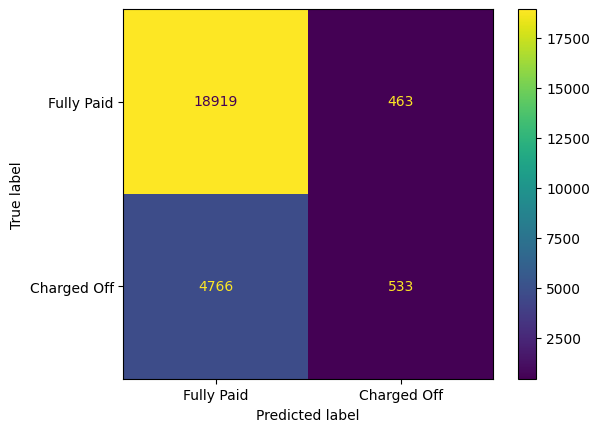

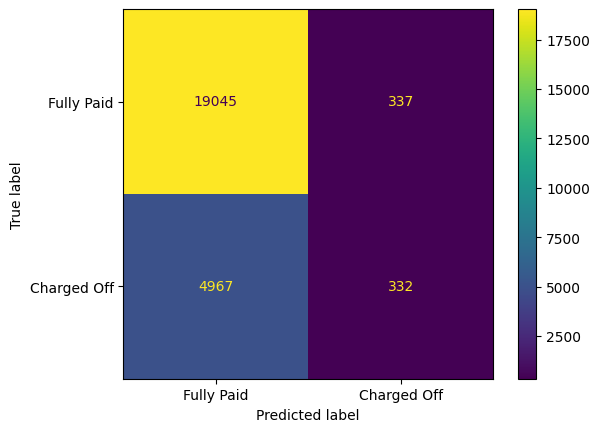

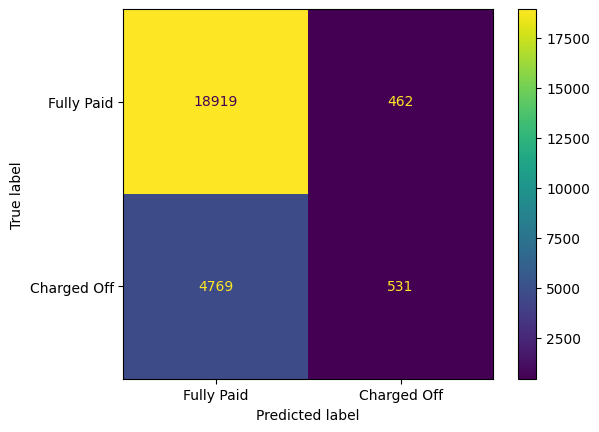

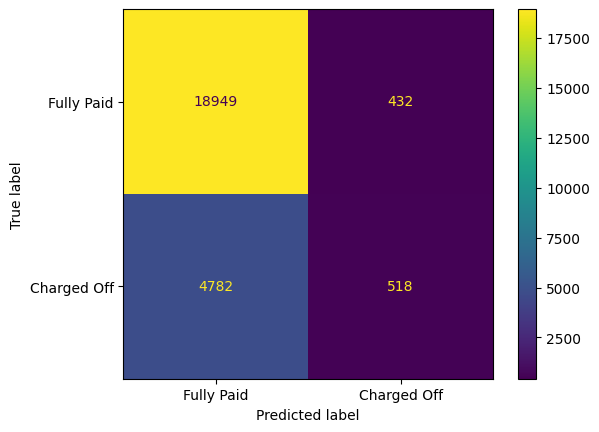

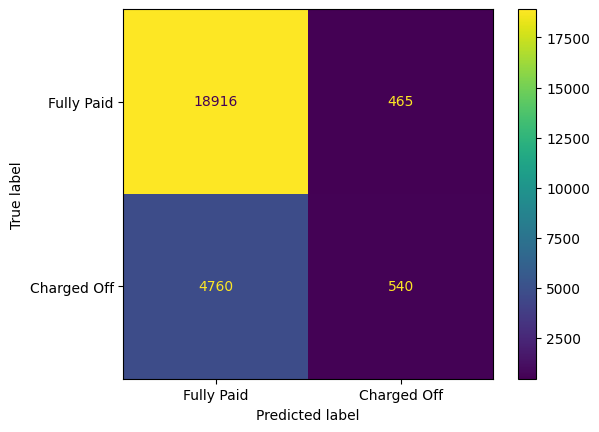

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

from src.data.cleaning import cleaning
from src.data.splitting import cross_val_split
from src.utils import train_validation_metrics

cleaned_sample = cleaning(df=raw_sample)
X_train_val, X_test, y_train_val, y_test = cross_val_split(df=cleaned_sample)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

f1_train = []

f1_val = []

model = LogisticRegression()

# enumerate the splits and summarize the distributions
for train_ix, val_ix in kfold.split(X_train_val, y_train_val): # here X is the train + validation and so is the y so this step should come after splitting the first time 
# select rows
    train_X, val_X = X_train_val.iloc[train_ix], X_train_val.iloc[val_ix]
    train_y, val_y = y_train_val.iloc[train_ix], y_train_val.iloc[val_ix]

    X_train, X_val, X_useless = processing_feature_selection_pipeline(X_train=train_X, X_val=val_X, X_test=X_test.copy(), y_train=train_y, features_to_keep=13)

    data_splits = X_train, X_val, X_useless, train_y, val_y, y_test

    training_f1, val_f1 = train_validation_metrics(model=model, data_splits=data_splits, LGB=False)

    f1_train.append(training_f1)

    f1_val.append(val_f1)

print(f'Average f1 train {np.mean(f1_train)}')

print(f'Average f1 validation {np.mean(f1_val)}')


# try implementing using the sklearn pipeline class 

